#### Imports

In [ ]:
import importlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import copy
import random
import os
from pathlib import Path
import pandas as pd
import time
import itertools
import re

from tqdm import tqdm
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import pickle

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

Current device: cuda


In [2]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\utils.py'>

In [3]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 22-Jun-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (10000, 9)
LUTdata shape: (10000, 25230)
wvl shape: (1, 4205)


In [4]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)

X shape: (10000, 9)
Y shape: (10000, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (8000, 9)
X_val shape: (1000, 9)
X_test shape: (1000, 9)

Y_tr shape: (8000, 6, 4205)
Y_val shape: (1000, 6, 4205)
Y_test shape: (1000, 6, 4205)


#### Convolutional Neural Network Pipeline

<ol>
    <li><b>Model and Dataset Definition</b>: Encoder-Decoder architecture.</li>
    <li><b>Training/Validation</b>: train loop with validation to choose the best model.</li>
    <li><b>External Testing</b> of the best selected model.</li>
</ol>

In [6]:
class MyDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [7]:
class Encoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(globals.N_INPUTS, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, z_dim),
            nn.SiLU()
        )

    def forward(self, x):
        return self.net(x)

In [8]:
# 1st ARCHITECTURE: upsample convolutions to reconstruct the full spectrum from a low-dimensional latent space calculated from the 9 inputs
class SpectralDecoder1(nn.Module):
    def __init__(self, z_dim=128, channels=16, initial_length=32):
        super().__init__()
        self.fc = nn.Linear(z_dim, channels * initial_length)
        self.initial_length = initial_length
        self.channels = channels

        # processing at low-res (16ch x 32len)
        self.initial_conv = nn.Sequential(
            nn.Conv1d(channels, 32, kernel_size=5, padding=2),
            nn.GroupNorm(8, 32),
            nn.SiLU()
        )

        # progressively upsample the sequence length
        self.upsample_pipeline = nn.Sequential(
            nn.ConvTranspose1d(32, 24, kernel_size=6, stride=4, padding=1),
            nn.GroupNorm(8, 24),
            nn.SiLU(),
            nn.ConvTranspose1d(24, 16, kernel_size=6, stride=4, padding=1),
            nn.GroupNorm(8, 16),
            nn.SiLU(),
            nn.ConvTranspose1d(16, 12, kernel_size=6, stride=4, padding=1),
            nn.GroupNorm(4, 12),
            nn.SiLU(),
            nn.ConvTranspose1d(12, 8, kernel_size=4, stride=2, padding=1),
            nn.GroupNorm(4, 8),
            nn.SiLU(),
        )

        # final adjustment to hit exactly 4205 and map to 1 output channel
        self.final_conv = nn.Conv1d(8, 1, kernel_size=5, padding=2)

    def forward(self, z):
        x = self.fc(z).view(z.size(0), self.channels, self.initial_length)
        x = self.initial_conv(x)
        x = self.upsample_pipeline(x)  # (N, 8, 4096)

        # from 4096, use a tiny interpolation just to cover the last 109 points
        x = F.interpolate(x, size=4205, mode="linear", align_corners=False)

        x = self.final_conv(x).squeeze(1)
        return x
    
class EmulatorSet1(nn.Module):
    def __init__(self, encoder_type="single"):
        super().__init__()
        self.encoder_type = encoder_type
        if encoder_type == "single":
            self.encoder = Encoder()
        else:
            self.encoder = nn.ModuleList([
                Encoder() for _ in range(globals.N_FUNCTIONS)
            ])

        # 6 decoders, one for each radiative transfer function
        self.decoders = nn.ModuleList([
            SpectralDecoder1() for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        if self.encoder_type == "single":
            z = self.encoder(x)
            outputs = [
                decoder(z)
                for decoder in self.decoders
            ]
        else:
            outputs = [
                decoder(encoder(x))
                for encoder, decoder in zip(self.encoder, self.decoders)
            ]
            
        # return prediction as one tensor of shape (N, 6, 4205)
        return torch.stack(outputs, dim=1)

In [9]:
# 2nd ARCHITECTURE: directly predict the PCA coefficients for each function from the latent space with MLP, without upsampling convolutions
class SpectralDecoder2(nn.Module):
    def __init__(self, z_dim=128, n_components=10):
        super().__init__()
        # map the latent space to the PCA coefficients
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.SiLU(),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Linear(128, n_components) # output shape: (N, 10)
        )

    def forward(self, z):
        return self.net(z)

class EmulatorSet2(nn.Module):
    def __init__(self, encoder_type="single", n_components=10):
        super().__init__()
        self.encoder_type = encoder_type
        if encoder_type == "single":
            self.encoder = Encoder()
        else:
            self.encoder = nn.ModuleList([
                Encoder() for _ in range(globals.N_FUNCTIONS)
            ])
        
        self.decoders = nn.ModuleList([
            SpectralDecoder2(z_dim=128, n_components=n_components) for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        if self.encoder_type == "single":
            z = self.encoder(x)
            outputs = [
                decoder(z)
                for decoder in self.decoders
            ]
        else:
            outputs = [
                decoder(encoder(x))
                for encoder, decoder in zip(self.encoder, self.decoders)
            ]
        # return prediction as one tensor of shape (N, 6, 10) - PCA coefficients for each function
        return torch.stack(outputs, dim=1)

In [10]:
# 3rd ARCHITECTURE: add convolutional processing to the latent space before predicting PCA coefficients, to allow the model to learn local relationships in the structured sequence space
# technically wrong, as the PCA-reduced space doesn't have a true spatial structure, but it allows us to experiment with convolutional processing
class SpectralDecoder3(nn.Module):
    def __init__(self, z_dim=128, n_components=10, initial_length=32, channels=16):
        super().__init__()
        self.initial_length = initial_length
        self.channels = channels

        # map latent space to a structured sequence space
        self.fc = nn.Linear(z_dim, channels * initial_length)

        # convolutions process features across the sequence dimension
        self.cnn = nn.Sequential(
            nn.Conv1d(channels, 32, kernel_size=5, padding=2),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.Conv1d(32, 24, kernel_size=5, padding=2),
            nn.GroupNorm(8, 24),
            nn.SiLU(),
            nn.Conv1d(24, 16, kernel_size=5, padding=2),
            nn.GroupNorm(4, 16),
            nn.SiLU(),
        )

        # collapse the remaining sequence length down to exactly 10 PCA dimensions
        self.to_pca = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * initial_length, 64),
            nn.SiLU(),
            nn.Linear(64, n_components) # final output shape: (N, 10)
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(z.size(0), self.channels, self.initial_length)
        x = self.cnn(x)
        pca_coefficients = self.to_pca(x)
        return pca_coefficients
    
class EmulatorSet3(nn.Module):
    def __init__(self, encoder_type="single", n_components=10):
        super().__init__()
        self.encoder_type = encoder_type
        if encoder_type == "single":
            self.encoder = Encoder()
        else:
            self.encoder = nn.ModuleList([
                Encoder() for _ in range(globals.N_FUNCTIONS)
            ])
        
        self.decoders = nn.ModuleList([
            SpectralDecoder3(z_dim=128, n_components=n_components) 
            for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        if self.encoder_type == "single":
            z = self.encoder(x)
            outputs = [
                decoder(z)
                for decoder in self.decoders
            ]
        else:
            outputs = [
                decoder(encoder(x))
                for encoder, decoder in zip(self.encoder, self.decoders)
            ]
        # return prediction as one tensor of shape (N, 6, 10) - PCA coefficients for each function
        return torch.stack(outputs, dim=1)

In [11]:
# 4th ARCHITECTURE: use squeeze and excite blocks to allow the model to learn which latent features are most important for each function, before predicting PCA coefficients
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.SiLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.fc(x)
        return x * weights
    
class SpectralDecoder4(nn.Module):
    def __init__(self, z_dim=128, n_components=10):
        super().__init__()

        self.se = SEBlock(z_dim)

        self.mlp = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.SiLU(),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Linear(128, n_components)
        )

    def forward(self, z):
        z = self.se(z)
        return self.mlp(z)
    
class EmulatorSet4(nn.Module):
    def __init__(self, encoder_type="single", n_components=10):
        super().__init__()

        self.encoder_type = encoder_type
        if encoder_type == "single":
            self.encoder = Encoder()
        else:
            self.encoder = nn.ModuleList([
                Encoder() for _ in range(globals.N_FUNCTIONS)
            ])

        self.decoders = nn.ModuleList([
            SpectralDecoder4(z_dim=128, n_components=n_components)
            for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        if self.encoder_type == "single":
            z = self.encoder(x)
            outputs = [
                decoder(z)
                for decoder in self.decoders
            ]
        else:
            outputs = [
                decoder(encoder(x))
                for encoder, decoder in zip(self.encoder, self.decoders)
            ]

        return torch.stack(outputs, dim=1)

In [12]:
# quick model test
model = EmulatorSet3(encoder_type="single").to(device)
model.eval()

# dummy input: (batch_size, 9)
X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32).to(device)
print("Input shape:", X_tr_tensor.shape)

with torch.no_grad():
    y_pred = model(X_tr_tensor)

# y is a tensor of shape (N, 6, 4205)
print("Output shape:", y_pred.shape)

summary(model, input_size=(globals.N_INPUTS,))

Input shape: torch.Size([8000, 9])
Output shape: torch.Size([8000, 6, 10])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             640
              SiLU-2                   [-1, 64]               0
            Linear-3                  [-1, 128]           8,320
              SiLU-4                  [-1, 128]               0
            Linear-5                  [-1, 128]          16,512
              SiLU-6                  [-1, 128]               0
           Encoder-7                  [-1, 128]               0
            Linear-8                  [-1, 512]          66,048
            Conv1d-9               [-1, 32, 32]           2,592
        GroupNorm-10               [-1, 32, 32]              64
             SiLU-11               [-1, 32, 32]               0
           Conv1d-12               [-1, 24, 32]           3,864
        GroupNorm-13        

Investigate scaled datasets.

In [13]:
# scaled outputs
y_scalers, Y_tr_scaled, Y_val_scaled = utils.scale_output_data(Y_tr, Y_val, scale_type="minmax")

print("Train scaled min:", Y_tr_scaled.min())
print("Val scaled min:", Y_val_scaled.min())

print(np.sum(Y_tr_scaled == 0))
print(np.sum(Y_val_scaled == 0))

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

Train scaled min: 0.0
Val scaled min: -0.017684102
1585565
195406


Using MRE as the loss function in this scenario would not be desirable, as the training loss would explode to very high values due to the high amount of training values near zero. Scaled or reduced data has many values that are zero or near zero, which would make the MRE explode. Using a wavelength mask would exclude deep absorption bands, but the MRE would still be calculated on the scaled and reduced data, which would not solve the exploding problem. MRE calculated on the restored data could be used as loss, but it would not be a meaningful objective, as it would be calculated on data that is fundamentally different from what the model actually sees.

In [ ]:
# ==================== EXPERIMENT GRID ====================
ARCHITECTURES = {
    "EmulatorSet1": EmulatorSet1,
    "EmulatorSet2": EmulatorSet2,
    "EmulatorSet3": EmulatorSet3,
    "EmulatorSet4": EmulatorSet4,
}

ENCODER_VERSIONS = [
    "single", 
    "multi",
]

SCALE_TYPES = [
    "minmax", 
    "standard",
]

# which model families use the full dataset vs. the reduced one
FULL_DS_MODELS    = {"EmulatorSet1"}
REDUCED_DS_MODELS = {"EmulatorSet2", "EmulatorSet3", "EmulatorSet4"}


def create_datasets(X_tr, X_val, Y_tr, Y_val, X_test, Y_test, verbose=True):
    train_ds = MyDataset(X_tr, Y_tr)
    val_ds = MyDataset(X_val, Y_val)
    test_ds = MyDataset(X_test, Y_test)

    if verbose:
        print("Train dataset length:", len(train_ds))
        print("Val dataset length:", len(val_ds))
        print("Test dataset length:", len(test_ds))

        # get item check
        x, y = train_ds.__getitem__(0)
        print("Input shape:", x.shape)
        print("Output shape:", y.shape)
        print()

    return train_ds, val_ds, test_ds


def prepare_all_experiments(X_tr, X_val, X_test, Y_tr, Y_val, Y_test, n_pca_components=10):
    config = {
        "x_scalers":               {},
        "y_scalers":               {},
        "y_scalers_reduced":       {},
        "pca_lists":               {},
        "train_ds_scaled":         {},
        "val_ds_scaled":           {},
        "test_ds_scaled":          {},
        "train_ds_reduced_scaled": {},
        "val_ds_reduced_scaled":   {},
        "test_ds_reduced_scaled":  {},
    }

    # PCA is fit on raw outputs — independent of scale type, so compute once
    pca_list, Y_tr_reduced, Y_val_reduced = utils.apply_pca(Y_tr, Y_val, n_components=n_pca_components)
    Y_test_reduced = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, n_pca_components))
    for i in range(globals.N_FUNCTIONS):
        Y_test_reduced[:, i, :] = pca_list[i].transform(Y_test[:, i, :])

    for scale_type in SCALE_TYPES:
        print(f"\n── Preparing [{scale_type}] ──────────────────────────────")

        # --- inputs ---
        x_scaler, X_tr_scaled, X_val_scaled = utils.scale_input_data(
            X_tr, X_val, scale_type=scale_type
        )
        X_test_scaled = x_scaler.transform(X_test)

        # --- full outputs ---
        y_scalers, Y_tr_scaled, Y_val_scaled = utils.scale_output_data(
            Y_tr, Y_val, scale_type=scale_type
        )
        Y_test_scaled = np.zeros_like(Y_test)
        for i in range(globals.N_FUNCTIONS):
            Y_test_scaled[:, i, :] = y_scalers[i].transform(Y_test[:, i, :])

        # --- reduced outputs ---
        y_scalers_reduced, Y_tr_reduced_scaled, Y_val_reduced_scaled = utils.scale_output_data(
            Y_tr_reduced, Y_val_reduced, scale_type=scale_type
        )
        Y_test_reduced_scaled = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, n_pca_components))
        for i in range(globals.N_FUNCTIONS):
            Y_test_reduced_scaled[:, i, :] = y_scalers_reduced[i].transform(Y_test_reduced[:, i, :])

        # --- datasets ---
        train_ds_scaled, val_ds_scaled, test_ds_scaled = create_datasets(
            X_tr_scaled, X_val_scaled, Y_tr_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled
        )
        train_ds_reduced_scaled, val_ds_reduced_scaled, test_ds_reduced_scaled = create_datasets(
            X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled, Y_val_reduced_scaled,
            X_test_scaled, Y_test_reduced_scaled
        )

        # --- store everything under the scale_type key ---
        config["x_scalers"][scale_type]               = x_scaler
        config["y_scalers"][scale_type]               = y_scalers
        config["y_scalers_reduced"][scale_type]       = y_scalers_reduced
        config["pca_lists"][scale_type]               = pca_list        # same for both
        config["train_ds_scaled"][scale_type]         = train_ds_scaled
        config["val_ds_scaled"][scale_type]           = val_ds_scaled
        config["test_ds_scaled"][scale_type]          = test_ds_scaled
        config["train_ds_reduced_scaled"][scale_type] = train_ds_reduced_scaled
        config["val_ds_reduced_scaled"][scale_type]   = val_ds_reduced_scaled
        config["test_ds_reduced_scaled"][scale_type]  = test_ds_reduced_scaled

    # training hyperparameters
    config["batch_size"] = 64
    config["n_epochs"]   = 100
    config["patience"]   = 25

    return config


# ==================== DATASET / SCALER ROUTER ====================
def get_loaders_and_scalers(model_name, scale_type, config):
    """Return (train_dl, val_dl, y_scalers) for a given experiment."""
    if model_name in FULL_DS_MODELS:
        train_ds = config["train_ds_scaled"][scale_type]
        val_ds   = config["val_ds_scaled"][scale_type]
        y_scalers = config["y_scalers"][scale_type]
        pca_list = None
    else:
        train_ds = config["train_ds_reduced_scaled"][scale_type]
        val_ds   = config["val_ds_reduced_scaled"][scale_type]
        y_scalers = config["y_scalers_reduced"][scale_type]
        pca_list = config["pca_lists"][scale_type]

    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    val_dl   = torch.utils.data.DataLoader(val_ds,   batch_size=config["batch_size"], shuffle=False)
    return train_ds, val_ds, train_dl, val_dl, y_scalers, pca_list


def calculate_metrics(y_pred, Y_batch, wavelengths, y_scalers, pca_list):
    is_scaled  = y_scalers is not None
    is_reduced = pca_list  is not None

    if is_scaled or is_reduced:
        # prepare tensors to hold the restored predictions and targets in original space
        y_pred_og_shape = torch.zeros((y_pred.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred.device)
        y_true_og_shape = torch.zeros((Y_batch.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=Y_batch.device)

        # inverse transform the scaling and PCA to get back to original space if needed
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred[:, i, :].cpu().detach().numpy()
            y_true_restored = Y_batch[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
                y_true_restored = y_scalers[i].inverse_transform(y_true_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
                y_true_restored = pca_list[i].inverse_transform(y_true_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_og_shape.device)
            y_true_og_shape[:, i, :] = torch.from_numpy(y_true_restored).to(y_true_og_shape.device)

        batch_train_mre_unscaled = utils.mre_score(y_true_og_shape.cpu().detach().numpy(), y_pred_og_shape.cpu().detach().numpy(), wavelengths)
        batch_train_mae_unscaled = utils.mae_score(y_true_og_shape.cpu().detach().numpy(), y_pred_og_shape.cpu().detach().numpy(), wavelengths)
    else:
        batch_train_mre_unscaled = utils.mre_score(Y_batch.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), wavelengths)
        batch_train_mae_unscaled = utils.mae_score(Y_batch.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), wavelengths)

    return batch_train_mre_unscaled, batch_train_mae_unscaled


# ==================== SINGLE EXPERIMENT ====================
def run_experiment(model_name, encoder_version, scale_type, config, device, wavelengths):
    dataset_size = int(re.search(r'\d+', Path(globals.CURRENT_TRAIN_FILE).stem).group())
    exp_id = f"{model_name}_{encoder_version}_{scale_type}_{dataset_size}"
    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {exp_id}")
    print(f"{'='*60}")

    # --- build model ---
    ModelClass = ARCHITECTURES[model_name]
    model = ModelClass(encoder_type=encoder_version).to(device)

    # --- data ---
    train_ds, val_ds, train_dl, val_dl, y_scalers, pca_list = get_loaders_and_scalers(
        model_name, scale_type, config
    )

    # --- optimiser / loss / scheduler ---
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.L1Loss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.2, patience=5
    )

    # --- early stopping state ---
    n_epochs        = config.get("n_epochs", 100)
    patience        = config.get("patience", 25)
    best_val_mre    = float("inf")
    patience_counter = 0
    best_model_wts  = copy.deepcopy(model.state_dict())
    history         = defaultdict(list)

    start_time = time.time()

    for epoch in range(n_epochs):
        # ---------- TRAIN ----------
        model.train()
        epoch_train_loss = epoch_train_mre = epoch_train_mae = 0.0
        # accumulate preds and targets to compute metrics once at the end of the loop to avoid aggregation artifacts
        all_preds   = []
        all_targets = []

        for X_batch, Y_batch in tqdm(train_dl, desc=f"[{exp_id}] E{epoch+1} Train", leave=False):
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, Y_batch)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * X_batch.size(0)
            all_preds.append(y_pred.detach().cpu())
            all_targets.append(Y_batch.cpu())

        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        epoch_train_mre, epoch_train_mae = calculate_metrics(all_preds, all_targets, wavelengths, y_scalers, pca_list)
        epoch_train_loss /= len(train_ds)

        # ---------- VALIDATE ----------
        model.eval()
        epoch_val_loss = epoch_val_mre = epoch_val_mae = 0.0
        all_preds   = []
        all_targets = []

        with torch.no_grad():
            for X_batch, Y_batch in tqdm(val_dl, desc=f"[{exp_id}] E{epoch+1} Val", leave=False):
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                y_pred = model(X_batch)
                loss   = criterion(y_pred, Y_batch)

                epoch_val_loss += loss.item() * X_batch.size(0)
                all_preds.append(y_pred.cpu())
                all_targets.append(Y_batch.cpu())

        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        epoch_val_mre, epoch_val_mae = calculate_metrics(all_preds, all_targets, wavelengths, y_scalers, pca_list)
        epoch_val_loss /= len(val_ds)

        scheduler.step(epoch_val_mre)

        # record
        history["train_loss"].append(epoch_train_loss)
        history["train_mre"].append(epoch_train_mre)
        history["train_mae"].append(epoch_train_mae)
        history["val_loss"].append(epoch_val_loss)
        history["val_mre"].append(epoch_val_mre)
        history["val_mae"].append(epoch_val_mae)

        print(
            f"  E{epoch+1:03d} | "
            f"train loss {epoch_train_loss:.5f}  mre {epoch_train_mre:.5f}  mae {epoch_train_mae:.5f} | "
            f"val loss {epoch_val_loss:.5f}  mre {epoch_val_mre:.5f}  mae {epoch_val_mae:.5f}"
        )

        # ---------- EARLY STOPPING ----------
        if epoch_val_mre < best_val_mre:
            best_val_mre   = epoch_val_mre
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("  --> best val MRE — weights saved")
        else:
            patience_counter += 1
            print(f"  --> no improvement ({patience_counter}/{patience})")
            if patience_counter >= patience:
                print("  !!! early stopping !!!")
                break

    elapsed = time.time() - start_time

    # reload best weights
    model.load_state_dict(best_model_wts)

    # persist model
    os.makedirs("nn_saves", exist_ok=True)
    torch.save(model.state_dict(), f"nn_saves/{exp_id}.pth")

    # save history
    with open(f"nn_saves/{exp_id}_history.pkl", "wb") as f:
        pickle.dump(history, f)

    # build result row
    idx_best = int(np.argmin(history["val_mre"]))
    result = {
        "experiment_id":  exp_id,
        "model":          model_name,
        "encoder":        encoder_version,
        "scale_type":     scale_type,
        "dataset_size":   dataset_size,
        "fit_time":       elapsed,
        "best_epoch":     idx_best + 1,
        "best_train_loss": history["train_loss"][idx_best],
        "best_val_loss":   history["val_loss"][idx_best],
        "best_train_mre":  history["train_mre"][idx_best],
        "best_val_mre":    history["val_mre"][idx_best],
        "best_train_mae":  history["train_mae"][idx_best],
        "best_val_mae":    history["val_mae"][idx_best],
    }
    return model, history, result


# ==================== FULL EXPERIMENT LOOP ====================
def run_all_experiments(config, device, wavelengths):
    results_path = Path("nn_saves/nn_results.csv")
    all_results  = []

    grid = list(itertools.product(ARCHITECTURES.keys(), ENCODER_VERSIONS, SCALE_TYPES))
    print(f"Total experiments to run: {len(grid)}")

    for model_name, encoder_version, scale_type in grid:
        try:
            model, history, result = run_experiment(
                model_name, encoder_version, scale_type,
                config, device, wavelengths
            )
            all_results.append(result)

            # append to CSV after every experiment so a crash doesn't lose data
            row_df = pd.DataFrame([result])
            row_df.to_csv(
                results_path,
                mode="a",
                header=not results_path.exists(),
                index=False,
            )
            print(f"  Saved results for {result['experiment_id']}\n")

        except Exception as e:
            print(f"  [ERROR] {model_name}__{encoder_version}__{scale_type} failed: {e}")
            continue

    summary = pd.DataFrame(all_results).sort_values("best_val_mre")
    print("\n===== EXPERIMENT SUMMARY (sorted by val MRE) =====")
    print(summary[["experiment_id", "best_val_mre", "best_val_mae", "best_epoch", "fit_time"]].to_string(index=False))
    return summary, model, history

In [15]:
config = prepare_all_experiments(X_tr, X_val, X_test, Y_tr, Y_val, Y_test)

---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------


── Preparing [minmax] ──────────────────────────────
---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

---------- Scaling ou

In [16]:
# ============================== !!CRITICAL CELL!! ==============================

summary, last_model, last_history = run_all_experiments(config, device, wavelengths)

Total experiments to run: 16

  EXPERIMENT: EmulatorSet1_single_minmax_10000


  E001 | train loss 0.10844  mre 0.14288  mae 17.86285 | val loss 0.03035  mre 0.03392  mae 4.10452
  --> best val MRE — weights saved


  E002 | train loss 0.02560  mre 0.02998  mae 3.63112 | val loss 0.02016  mre 0.02112  mae 3.04990
  --> best val MRE — weights saved


  E003 | train loss 0.01935  mre 0.02158  mae 2.54957 | val loss 0.01632  mre 0.01691  mae 2.00166
  --> best val MRE — weights saved


  E004 | train loss 0.01621  mre 0.01781  mae 2.01612 | val loss 0.01503  mre 0.01519  mae 1.88128
  --> best val MRE — weights saved


...

  E096 | train loss 0.02075  mre 0.00123  mae 0.15543 | val loss 0.02049  mre 0.00128  mae 0.15690
  --> no improvement (2/25)


  E097 | train loss 0.02075  mre 0.00123  mae 0.15541 | val loss 0.02049  mre 0.00127  mae 0.15724
  --> no improvement (3/25)


  E098 | train loss 0.02075  mre 0.00123  mae 0.15538 | val loss 0.02048  mre 0.00127  mae 0.15719
  --> no improvement (4/25)


  E099 | train loss 0.02075  mre 0.00123  mae 0.15543 | val loss 0.02048  mre 0.00127  mae 0.15690
  --> no improvement (5/25)


  E100 | train loss 0.02075  mre 0.00123  mae 0.15533 | val loss 0.02048  mre 0.00127  mae 0.15717
  --> no improvement (6/25)
  Saved results for EmulatorSet4_multi_standard_10000


===== EXPERIMENT SUMMARY (sorted by val MRE) =====
                     experiment_id  best_val_mre  best_val_mae  best_epoch   fit_time
  EmulatorSet3_single_minmax_10000      0.000969      0.111109          96 793.746402
EmulatorSet4_single_standard_10000      0.001071      0.132132         100 605.449314
   EmulatorSet3_multi_minmax_10000      0.001115      0.119053          98 805.632896
EmulatorSet2_single_standard_10000      0.001143      0.138685          98 580.186641
 EmulatorSet3_multi_standard_10000      0.001238      0.153114          96 804.360499
 EmulatorSet4_multi_standard_10000      0.001273      0.156810          94 632.977189
EmulatorSet3_single_standard_10000      0.001311      0.161039          97 796.381909
   EmulatorSet4_multi_minmax_10000      0.001474      0.159235          79 632

In [18]:
summary

,experiment_id,model,encoder,scale_type,dataset_size,fit_time,best_epoch,best_train_loss,best_val_loss,best_train_mre,best_val_mre,best_train_mae,best_val_mae
8,EmulatorSet3_single_minmax_10000,EmulatorSet3,single,minmax,10000,793.746402,96,0.002185,0.002164,0.000950,0.000969,0.111073,0.111109
13,EmulatorSet4_single_standard_10000,EmulatorSet4,single,standard,10000,605.449314,100,0.019993,0.019780,0.001033,0.001071,0.129294,0.132132
10,EmulatorSet3_multi_minmax_10000,EmulatorSet3,multi,minmax,10000,805.632896,98,0.002316,0.002294,0.001094,0.001115,0.121058,0.119053
5,EmulatorSet2_single_standard_10000,EmulatorSet2,single,standard,10000,580.186641,98,0.019770,0.019546,0.001122,0.001143,0.136631,0.138685
11,EmulatorSet3_multi_standard_10000,EmulatorSet3,multi,standard,10000,804.360499,96,0.017508,0.017574,0.001161,0.001238,0.144344,0.153114
15,EmulatorSet4_multi_standard_10000,EmulatorSet4,multi,standard,10000,632.977189,94,0.020753,0.020484,0.001227,0.001273,0.155539,0.156810
9,EmulatorSet3_single_standard_10000,EmulatorSet3,single,standard,10000,796.381909,97,0.018637,0.018710,0.001233,0.001311,0.151798,0.161039
14,EmulatorSet4_multi_minmax_10000,EmulatorSet4,multi,minmax,10000,632.440834,79,0.002761,0.002695,0.001456,0.001474,0.163270,0.159235
7,EmulatorSet2_multi_standard_10000,EmulatorSet2,multi,standard,10000,607.487307,100,0.021944,0.021594,0.001495,0.001525,0.181377,0.183825
12,EmulatorSet4_single_minmax_10000,EmulatorSet4,single,minmax,10000,606.511677,97,0.002797,0.002743,0.001511,0.001547,0.162551,0.159867


Average Fit Time by Dataset Size
 dataset_size  avg_fit_time
          500    111.891453
         2000    195.761592
        10000    728.191658

Average Best Val MRE by Dataset Size & Model
 dataset_size        model  avg_best_val_mre
          500 EmulatorSet1          0.007801
          500 EmulatorSet2          0.005822
          500 EmulatorSet3          0.007190
          500 EmulatorSet4          0.005671
         2000 EmulatorSet1          0.006230
         2000 EmulatorSet2          0.002889
         2000 EmulatorSet3          0.002675
         2000 EmulatorSet4          0.002516
        10000 EmulatorSet1          0.004820
        10000 EmulatorSet2          0.001686
        10000 EmulatorSet3          0.001158
        10000 EmulatorSet4          0.001341

Average Best Val MAE by Dataset Size & Model
 dataset_size        model  avg_best_val_mae
          500 EmulatorSet1          0.810456
          500 EmulatorSet2          0.660718
          500 EmulatorSet3          0.82942

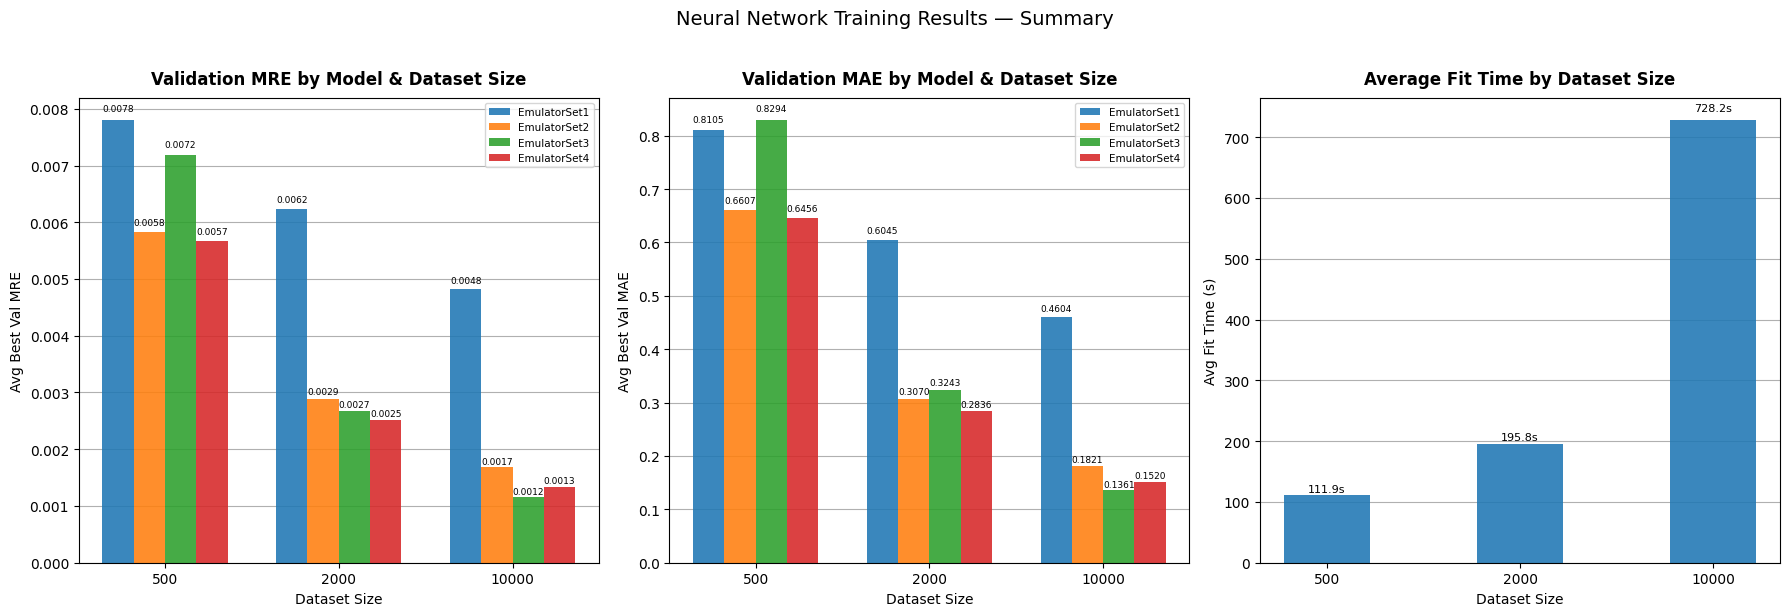


Figure saved to nn_results/nn_results_analysis.png


In [ ]:
# results csv analysis
results_df = pd.read_csv("nn_saves/nn_results.csv")


# ── average fit time per dataset size ────────────────────────────────────
avg_fit_time = (
    results_df.groupby("dataset_size")["fit_time"]
    .mean()
    .rename("avg_fit_time")
    .reset_index()
)
print("=" * 60)
print("Average Fit Time by Dataset Size")
print("=" * 60)
print(avg_fit_time.to_string(index=False))


# ── average best_val_mre per dataset size AND model ───────────────────────
avg_val_mre = (
    results_df.groupby(["dataset_size", "model"])["best_val_mre"]
    .mean()
    .rename("avg_best_val_mre")
    .reset_index()
)
print("\n" + "=" * 60)
print("Average Best Val MRE by Dataset Size & Model")
print("=" * 60)
print(avg_val_mre.to_string(index=False))


# ── average best_val_mae per dataset size AND model ───────────────────────
avg_val_mae = (
    results_df.groupby(["dataset_size", "model"])["best_val_mae"]
    .mean()
    .rename("avg_best_val_mae")
    .reset_index()
)
print("\n" + "=" * 60)
print("Average Best Val MAE by Dataset Size & Model")
print("=" * 60)
print(avg_val_mae.to_string(index=False))


# ── average best_val_mre and best_val_mae per model (across all dataset sizes) ──
avg_metrics_by_model = (
    results_df.groupby("model")[["best_val_mre", "best_val_mae"]]
    .mean()
    .rename(columns={
        "best_val_mre": "avg_best_val_mre",
        "best_val_mae": "avg_best_val_mae"
    })
    .reset_index()
)

print("\n" + "=" * 60)
print("Average Best Val MRE & MAE by Model (Across Dataset Sizes)")
print("=" * 60)
print(avg_metrics_by_model.to_string(index=False))


# ── average best_val_mre and best_val_mae per dataset size (across models) ──
avg_metrics_by_dataset_size = (
    results_df.groupby("dataset_size")[["best_val_mre", "best_val_mae"]]
    .mean()
    .rename(columns={
        "best_val_mre": "avg_best_val_mre",
        "best_val_mae": "avg_best_val_mae"
    })
    .reset_index()
)

print("\n" + "=" * 60)
print("Average Best Val MRE & MAE by Dataset Size (Across Models)")
print("=" * 60)
print(avg_metrics_by_dataset_size.to_string(index=False))


# ── visualisation ─────────────────────────────────────────────────────────
models       = sorted(results_df["model"].unique())
dataset_sizes = sorted(results_df["dataset_size"].unique())

# pivot tables for grouped bars
mre_pivot = avg_val_mre.pivot(index="dataset_size", columns="model", values="avg_best_val_mre")
mae_pivot = avg_val_mae.pivot(index="dataset_size", columns="model", values="avg_best_val_mae")
fit_pivot = avg_fit_time.set_index("dataset_size")[["avg_fit_time"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Neural Network Training Results — Summary", fontsize=14, y=1.02)

x      = np.arange(len(dataset_sizes))
n_mdl  = len(models)
width  = 0.18
offsets = np.linspace(-(n_mdl - 1) / 2, (n_mdl - 1) / 2, n_mdl) * width


def _grouped_bars(ax, pivot, ylabel, title):
    for i, mdl in enumerate(models):
        vals = pivot[mdl].values if mdl in pivot.columns else np.zeros(len(dataset_sizes))
        bars = ax.bar(x + offsets[i], vals, width, label=mdl,
                      alpha=0.88, linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h * 1.015,
                    f"{h:.4f}", ha="center", va="bottom", fontsize=6.5)
    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in dataset_sizes])
    ax.set_xlabel("Dataset Size")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold", pad=10)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.legend(fontsize=7.5, loc="upper right")


# panel 1 — pal MRE
_grouped_bars(axes[0], mre_pivot, "Avg Best Val MRE", "Validation MRE by Model & Dataset Size")

# panel 2 — pal MAE
_grouped_bars(axes[1], mae_pivot, "Avg Best Val MAE", "Validation MAE by Model & Dataset Size")

# panel 3 — fit time (single series, no model split)
fit_vals = [fit_pivot.loc[s, "avg_fit_time"] for s in dataset_sizes]
bars = axes[2].bar(x, fit_vals, width=0.45, alpha=0.88, linewidth=0)
for bar in bars:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width() / 2, h * 1.015,
                 f"{h:.1f}s", ha="center", va="bottom", fontsize=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels([str(s) for s in dataset_sizes])
axes[2].set_xlabel("Dataset Size")
axes[2].set_ylabel("Avg Fit Time (s)")
axes[2].set_title("Average Fit Time by Dataset Size", fontweight="bold", pad=10)
axes[2].yaxis.grid(True)
axes[2].set_axisbelow(True)

plt.tight_layout()
plt.savefig("nn_saves/nn_results_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved to nn_saves/nn_results_analysis.png")

In [24]:
# best model row load
# best_model = results_df.loc[results_df["best_val_mre"].idxmin()]
# print(best_model)

best_model = results_df.loc[results_df["experiment_id"] == "EmulatorSet4_single_standard_10000"].iloc[0]
print(best_model)

experiment_id      EmulatorSet4_single_standard_10000
model                                    EmulatorSet4
encoder                                        single
scale_type                                   standard
dataset_size                                    10000
fit_time                                   605.449314
best_epoch                                        100
best_train_loss                              0.019993
best_val_loss                                 0.01978
best_train_mre                               0.001033
best_val_mre                                 0.001071
best_train_mae                               0.129294
best_val_mae                                 0.132132
Name: 45, dtype: object


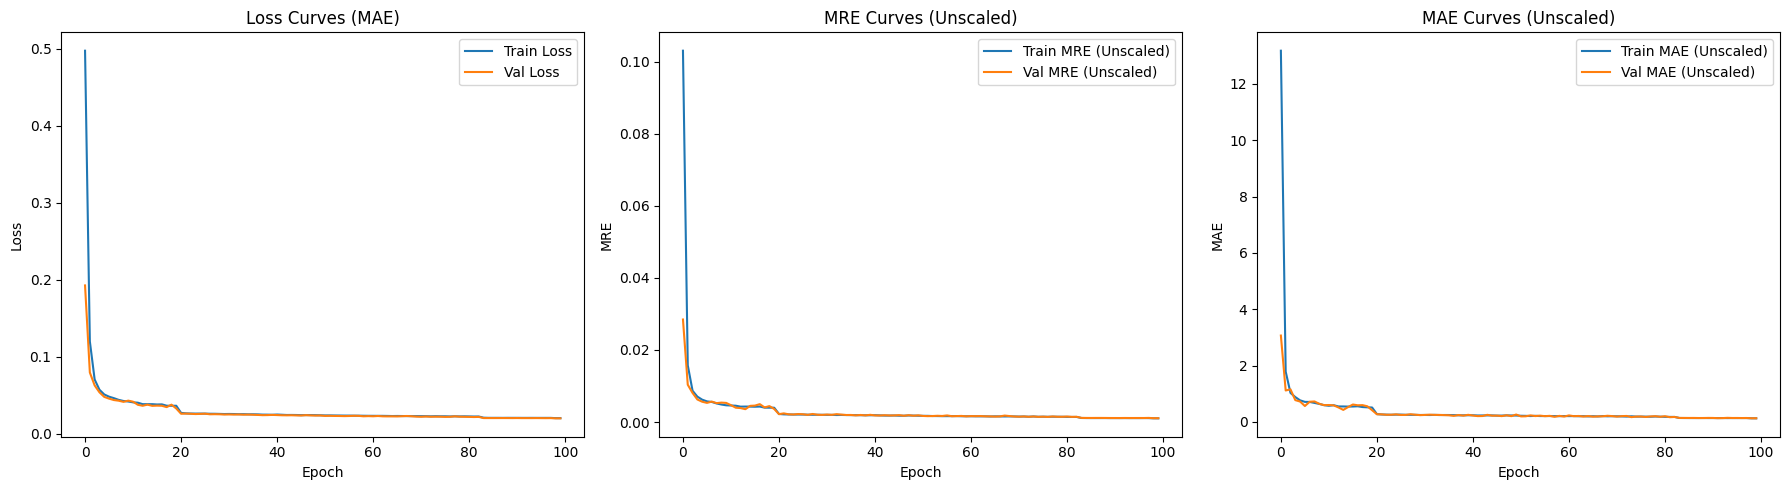

In [ ]:
# history load
with open(f"nn_saves/{best_model['experiment_id']}_history.pkl", "rb") as f:
    history = pickle.load(f)

# history plotting
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curves (MAE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["train_mre"], label="Train MRE (Unscaled)")
plt.plot(history["val_mre"], label="Val MRE (Unscaled)")
plt.title("MRE Curves (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MRE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_mae"], label="Train MAE (Unscaled)")
plt.plot(history["val_mae"], label="Val MAE (Unscaled)")
plt.title("MAE Curves (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# load best model
model = ARCHITECTURES[best_model["model"]](encoder_type=best_model["encoder"]).to(device)
model.load_state_dict(torch.load(f"nn_saves/{best_model['experiment_id']}.pth", map_location=device))

if best_model["model"] in FULL_DS_MODELS:
    test_ds = config["test_ds_scaled"][best_model["scale_type"]]
    y_scalers = config["y_scalers"][best_model["scale_type"]]
    pca_list = None
else:
    test_ds = config["test_ds_reduced_scaled"][best_model["scale_type"]]
    y_scalers = config["y_scalers_reduced"][best_model["scale_type"]]
    pca_list = config["pca_lists"][best_model["scale_type"]]

Testing MRE: 0.0018154179
Path Radiance MRE: 0.0035
Direct Solar Irradiance MRE: 0.0009
Diffuse Solar Irradiance MRE: 0.0026
Spherical Albedo MRE: 0.0019
Direct Transmittance MRE: 0.0004
Diffuse Transmittance MRE: 0.0016


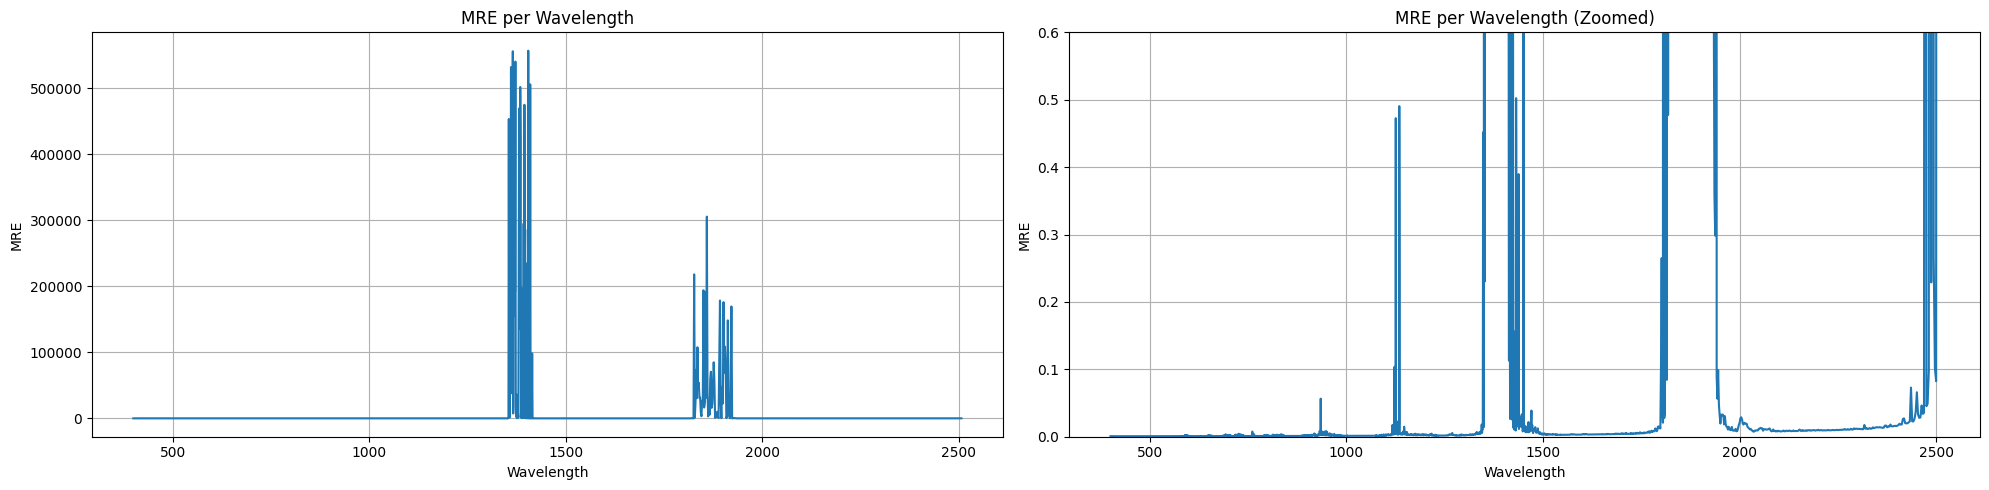

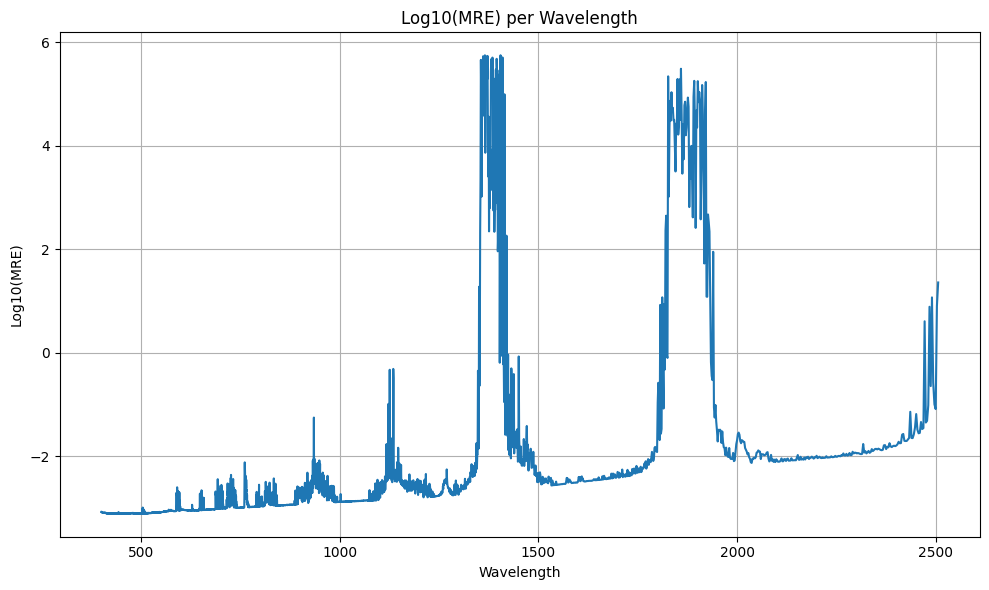

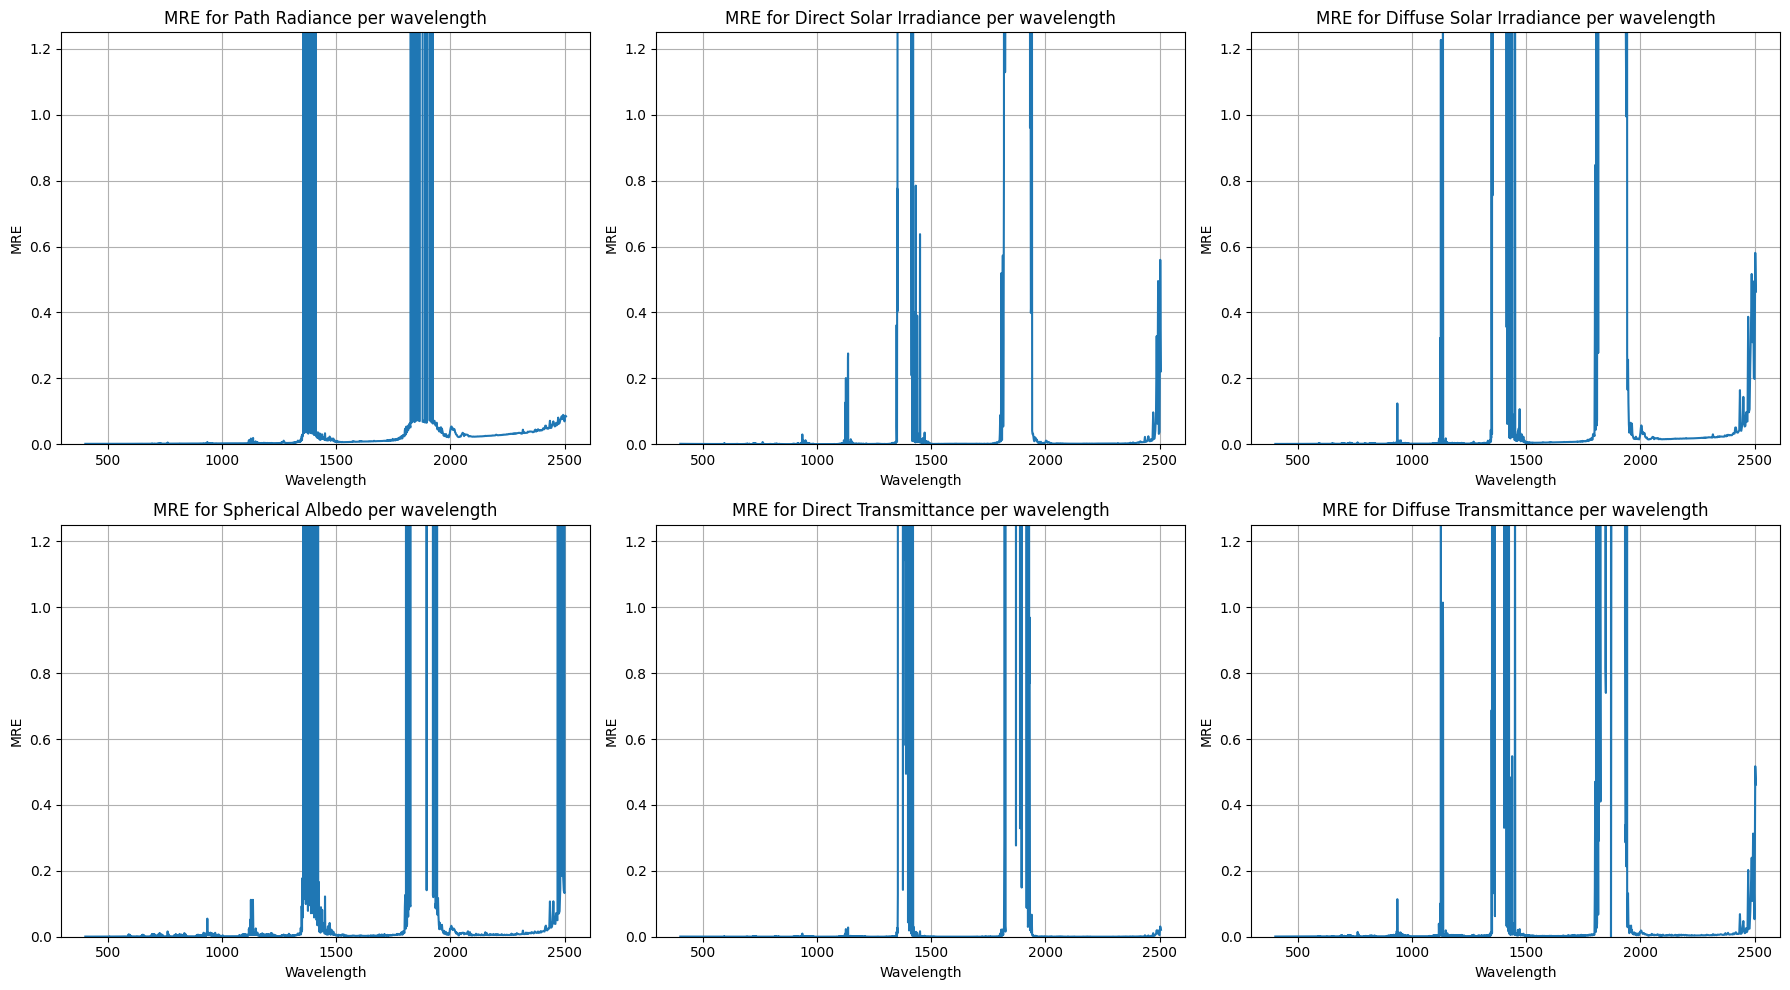

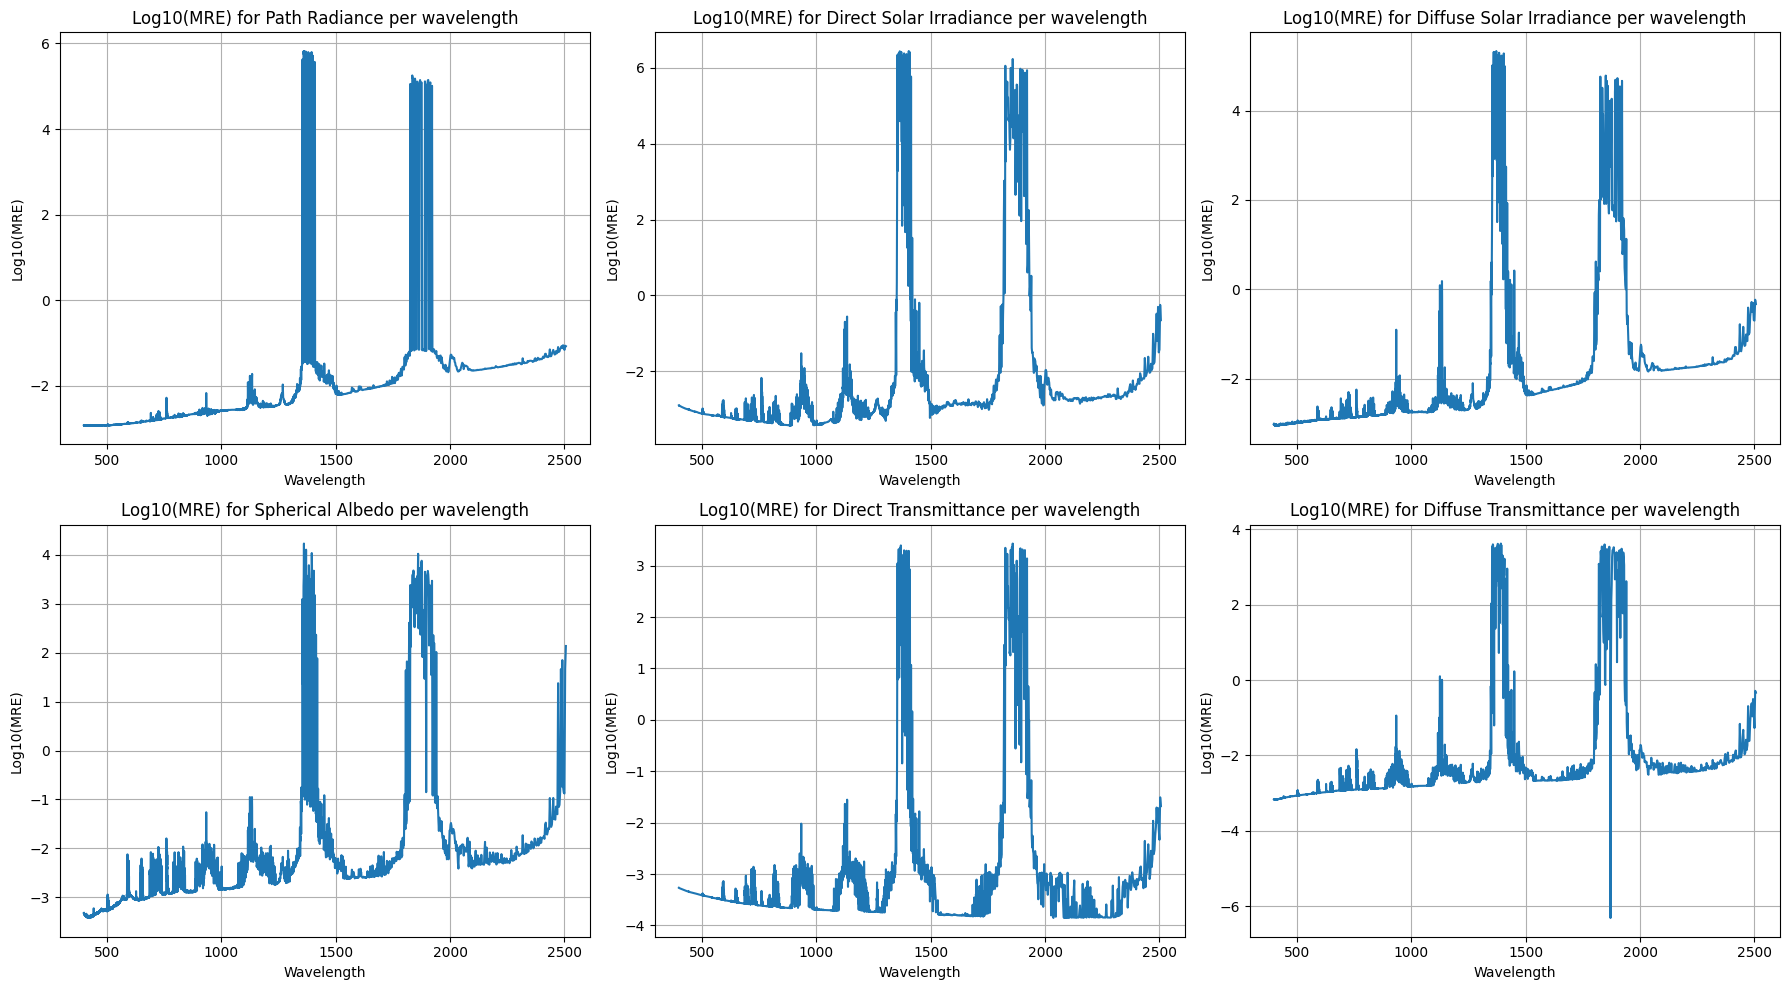

In [ ]:
# predict on test set for other metrics and visualization
X_test_tensor = torch.tensor(
    config["x_scalers"][best_model["scale_type"]].transform(X_test),
    dtype=torch.float32
).to(device)

is_scaled  = y_scalers is not None
is_reduced = pca_list  is not None
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor)
    if is_scaled or is_reduced:
        y_pred_og_shape = torch.zeros((y_pred_test.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred_test.device)
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred_test[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_test.device)
        y_pred_test = y_pred_og_shape

y_pred_test_np = y_pred_test.cpu().numpy()

mre = utils.mre_score(Y_test, y_pred_test_np, wavelengths)
print("Testing MRE:", mre)

mre_per_func = utils.mre_score(Y_test, y_pred_test_np, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{globals.function_names_plots[i]} MRE: {mre_per_func[i]:.4f}")

mre_per_wvl = utils.mre_score(Y_test, y_pred_test_np, wavelengths, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
axes[0].plot(wavelengths, mre_per_wvl)
axes[0].set_xlabel("Wavelength")
axes[0].set_ylabel("MRE")
axes[0].set_title("MRE per Wavelength")
axes[0].grid()
axes[1].plot(wavelengths, mre_per_wvl)
axes[1].set_ylim(0, 0.6)
axes[1].set_xlabel("Wavelength")
axes[1].set_ylabel("MRE")
axes[1].set_title("MRE per Wavelength (Zoomed)")
axes[1].grid()
plt.tight_layout()
plt.show()

# MRE per wavelength again but in log scale to better visualize small values
mre_per_wvl_log = np.log10(mre_per_wvl + 1e-10)  # add small value to avoid log(0)
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, mre_per_wvl_log)
plt.xlabel("Wavelength")
plt.ylabel("Log10(MRE)")
plt.title("Log10(MRE) per Wavelength")
plt.grid()
plt.tight_layout()
plt.show()

mre_per_func_wvl = utils.mre_score(Y_test, y_pred_test_np, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mre_per_func_wvl[i])
    axes[i].set_ylim(0, 1.25)
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MRE")
    axes[i].set_title(f"MRE for {globals.function_names_plots[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

# MRE per function again but in log scale to better visualize small values
mre_per_func_wvl_log = np.log10(mre_per_func_wvl + 1e-10)  # add small value to avoid log(0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mre_per_func_wvl_log[i])
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("Log10(MRE)")
    axes[i].set_title(f"Log10(MRE) for {globals.function_names_plots[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

Testing MAE: 0.14876427
Path Radiance MAE: 0.0276
Direct Solar Irradiance MAE: 0.5764
Diffuse Solar Irradiance MAE: 0.2850
Spherical Albedo MAE: 0.0001
Direct Transmittance MAE: 0.0002
Diffuse Transmittance MAE: 0.0002


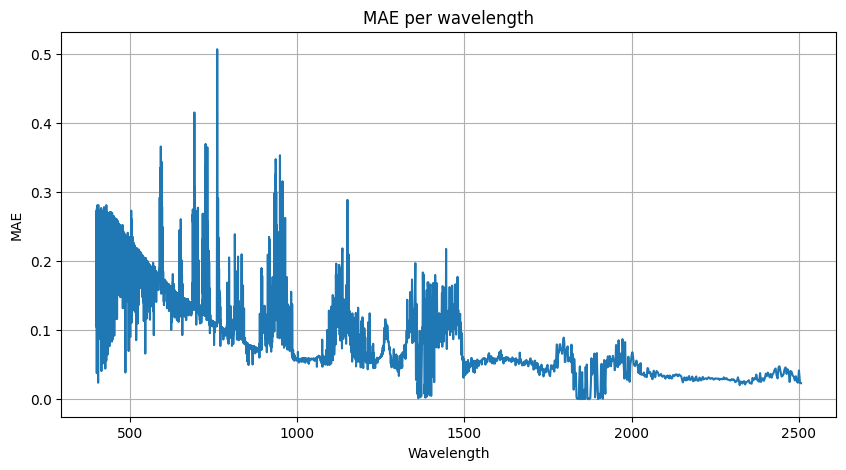

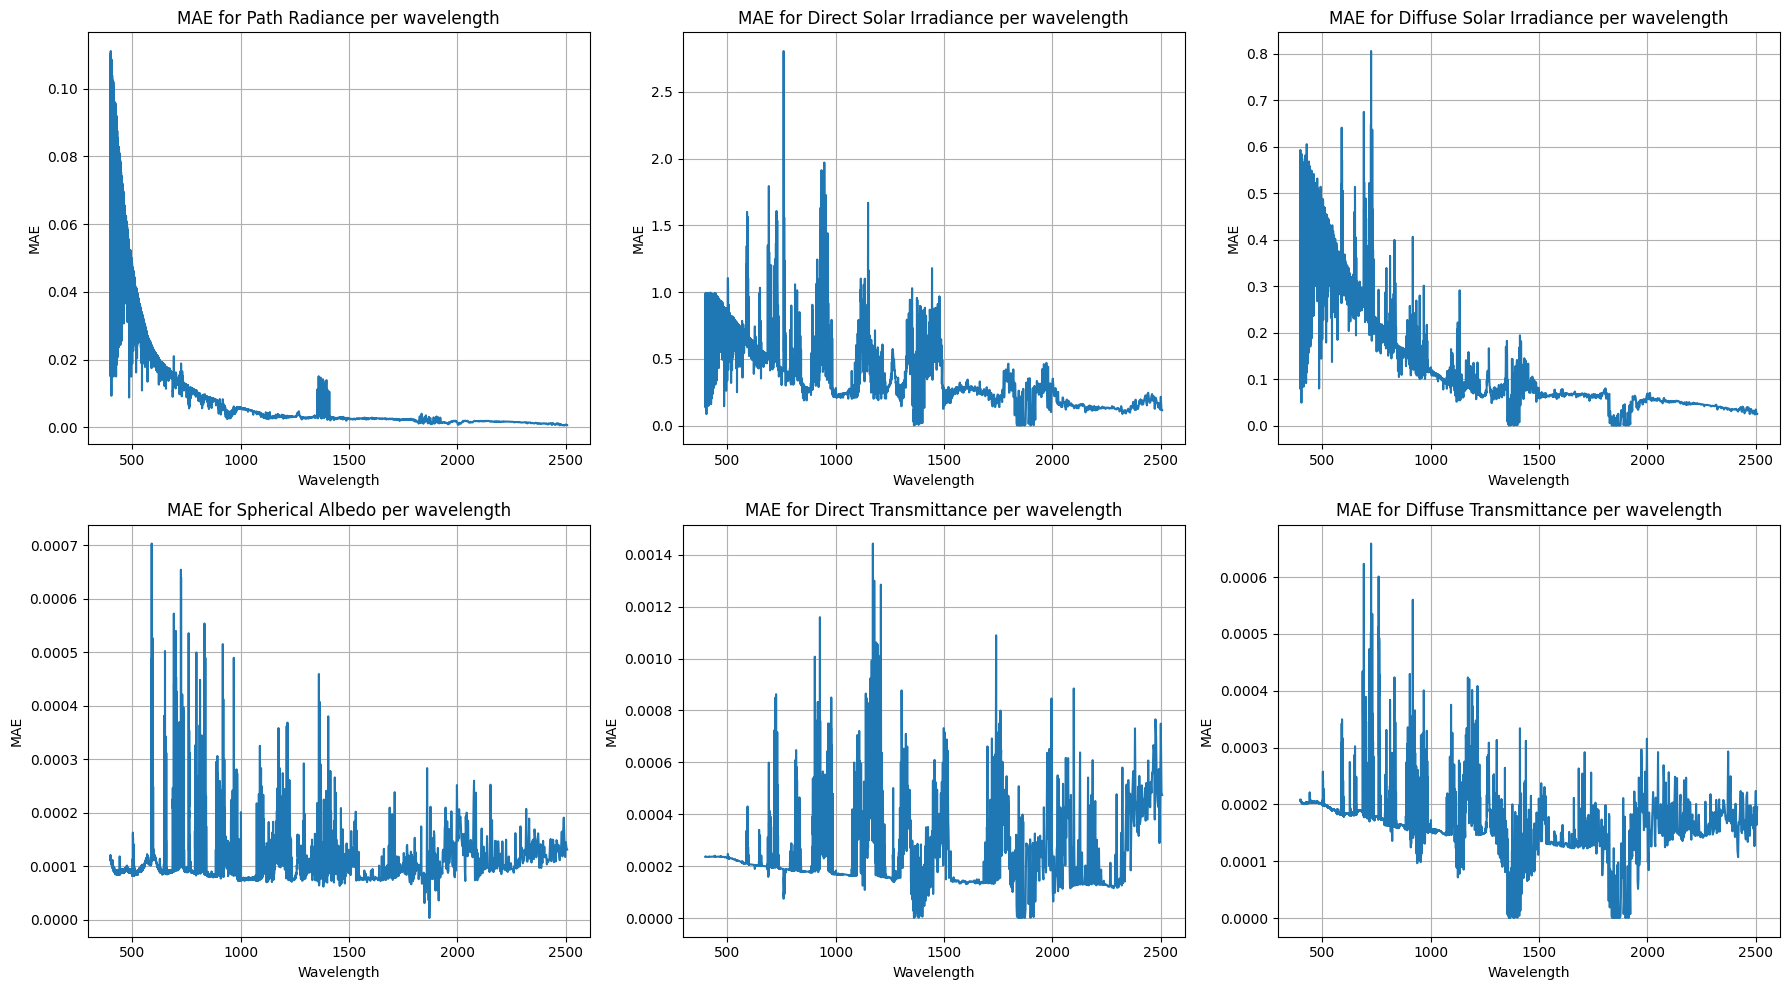

In [ ]:
mae = utils.mae_score(Y_test, y_pred_test_np, wavelengths)
print("Testing MAE:", mae)

mae_per_func = utils.mae_score(Y_test, y_pred_test_np, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{globals.function_names_plots[i]} MAE: {mae_per_func[i]:.4f}")

mae_per_wvl = utils.mae_score(Y_test, y_pred_test_np, wavelengths, axis=1)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mae_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MAE")
plt.title("MAE per wavelength")
plt.grid()
plt.show()

mae_per_func_wvl = utils.mae_score(Y_test, y_pred_test_np, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mae_per_func_wvl[i])
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MAE")
    axes[i].set_title(f"MAE for {globals.function_names_plots[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

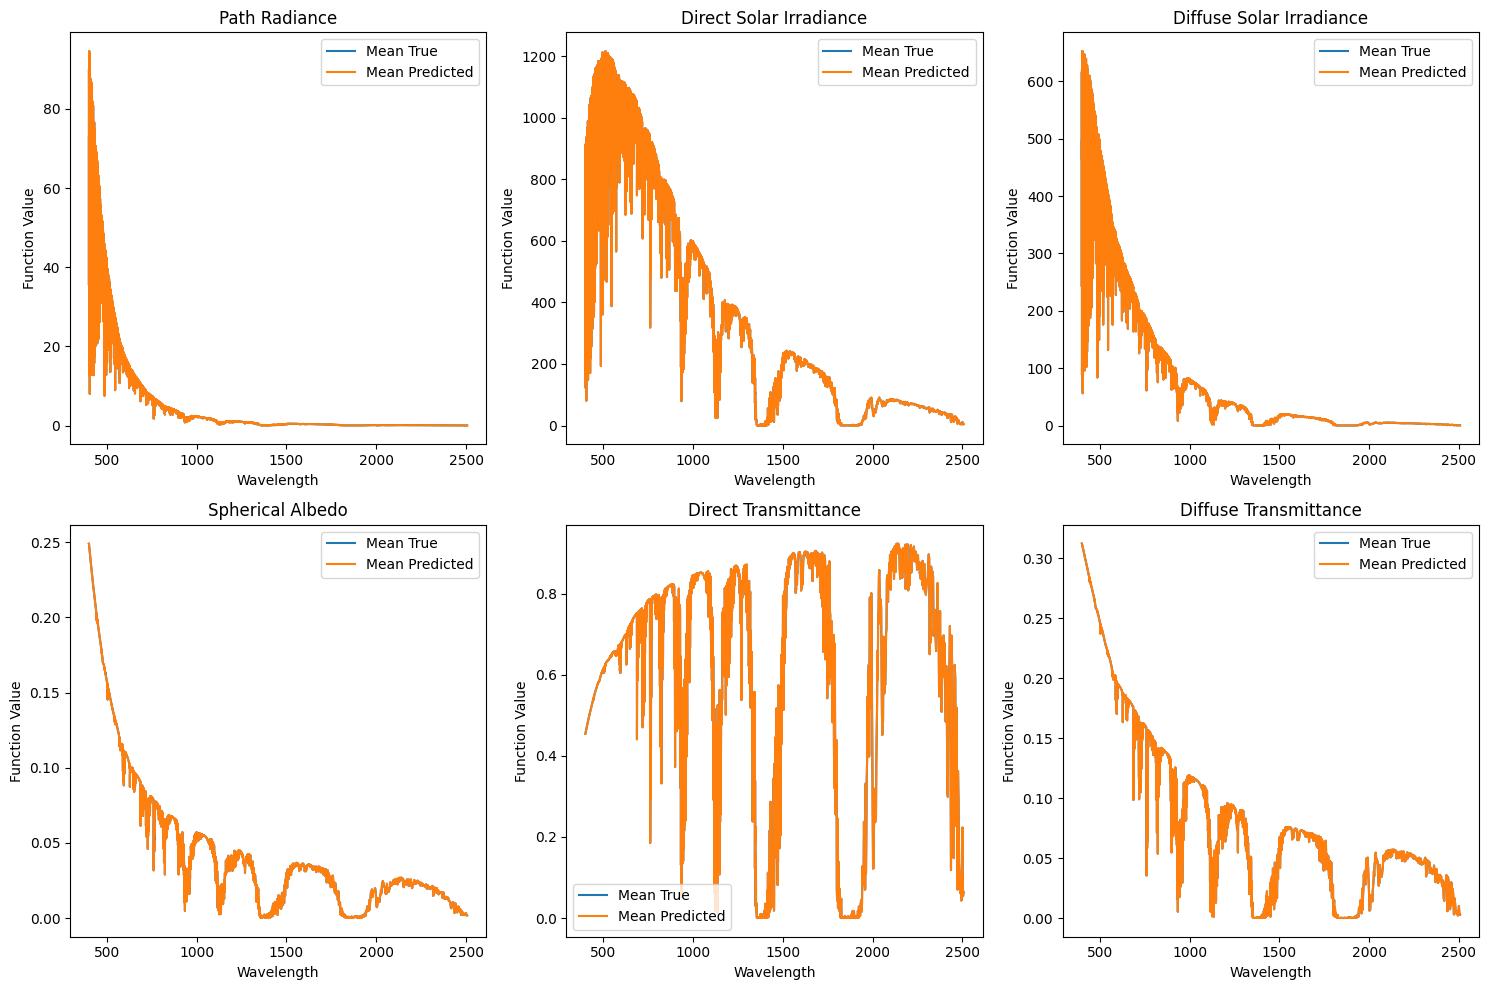

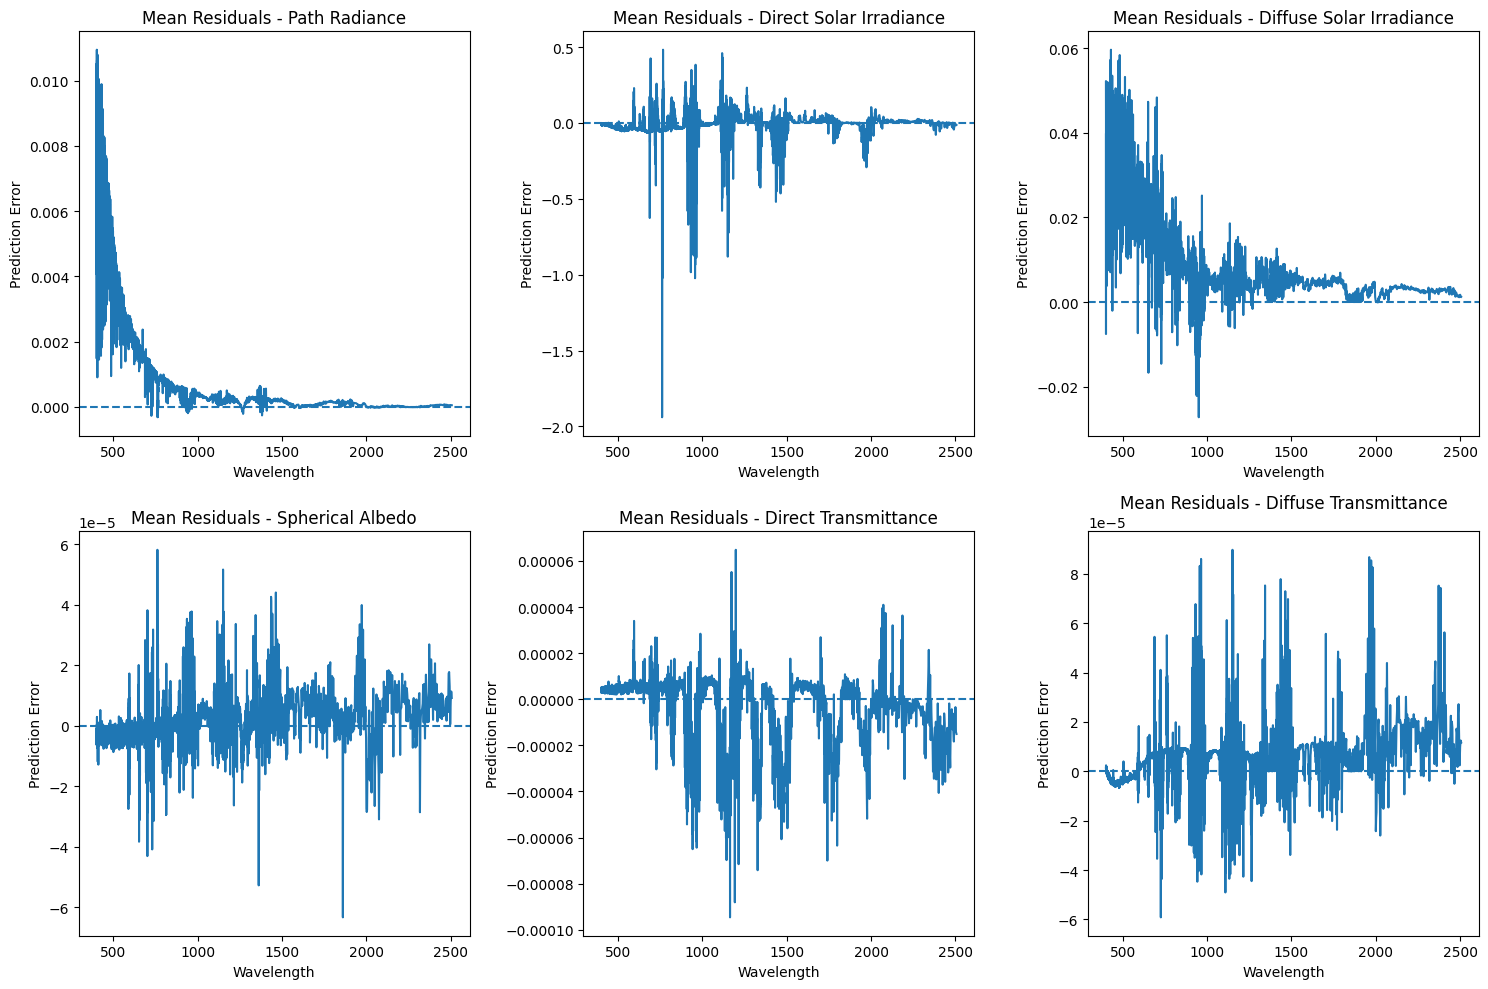

In [ ]:
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)
    plt.plot(wavelengths, np.mean(Y_test[:, i, :], axis=0), label="Mean True")
    plt.plot(wavelengths, np.mean(y_pred_test_np[:, i, :], axis=0), label="Mean Predicted")
    plt.title(f"{globals.function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()

# --- residuals for all samples ---
residuals = y_pred_test_np - Y_test

# mean residual across samples
mean_residuals = np.mean(residuals, axis=0)  # shape: (6, 4205)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, mean_residuals[i])
    plt.axhline(0, linestyle="--")

    plt.title(f"Mean Residuals - {globals.function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()

Load the test csv and apply the model to measure inference runtime.

In [35]:
X_test_csv = utils.load_test_csv(globals.CURRENT_TEST_FILE)
print(f"Test inputs from CSV shape: {X_test_csv.shape}")

is_scaled  = y_scalers is not None
is_reduced = pca_list  is not None
model.eval()

start_time_test_csv = time.time()

# scale test inputs with the same scaler used for training
X_test_csv_scaled = config["x_scalers"][best_model["scale_type"]].transform(X_test_csv)

X_test_tensor = torch.tensor(X_test_csv_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_test = model(X_test_tensor)
    if is_scaled or is_reduced:
        y_pred_og_shape = torch.zeros((y_pred_test.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred_test.device)
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred_test[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_test.device)
        y_pred_test = y_pred_og_shape
end_time_test_csv = time.time()

y_pred_test_np = y_pred_test.cpu().numpy()

print(f"Time taken to predict on test CSV: {end_time_test_csv - start_time_test_csv:.2f} seconds")
print("Predictions on test CSV shape:", y_pred_test_np.shape)

Test inputs from CSV shape: (10000, 9)
Time taken to predict on test CSV: 0.48 seconds
Predictions on test CSV shape: (10000, 6, 4205)


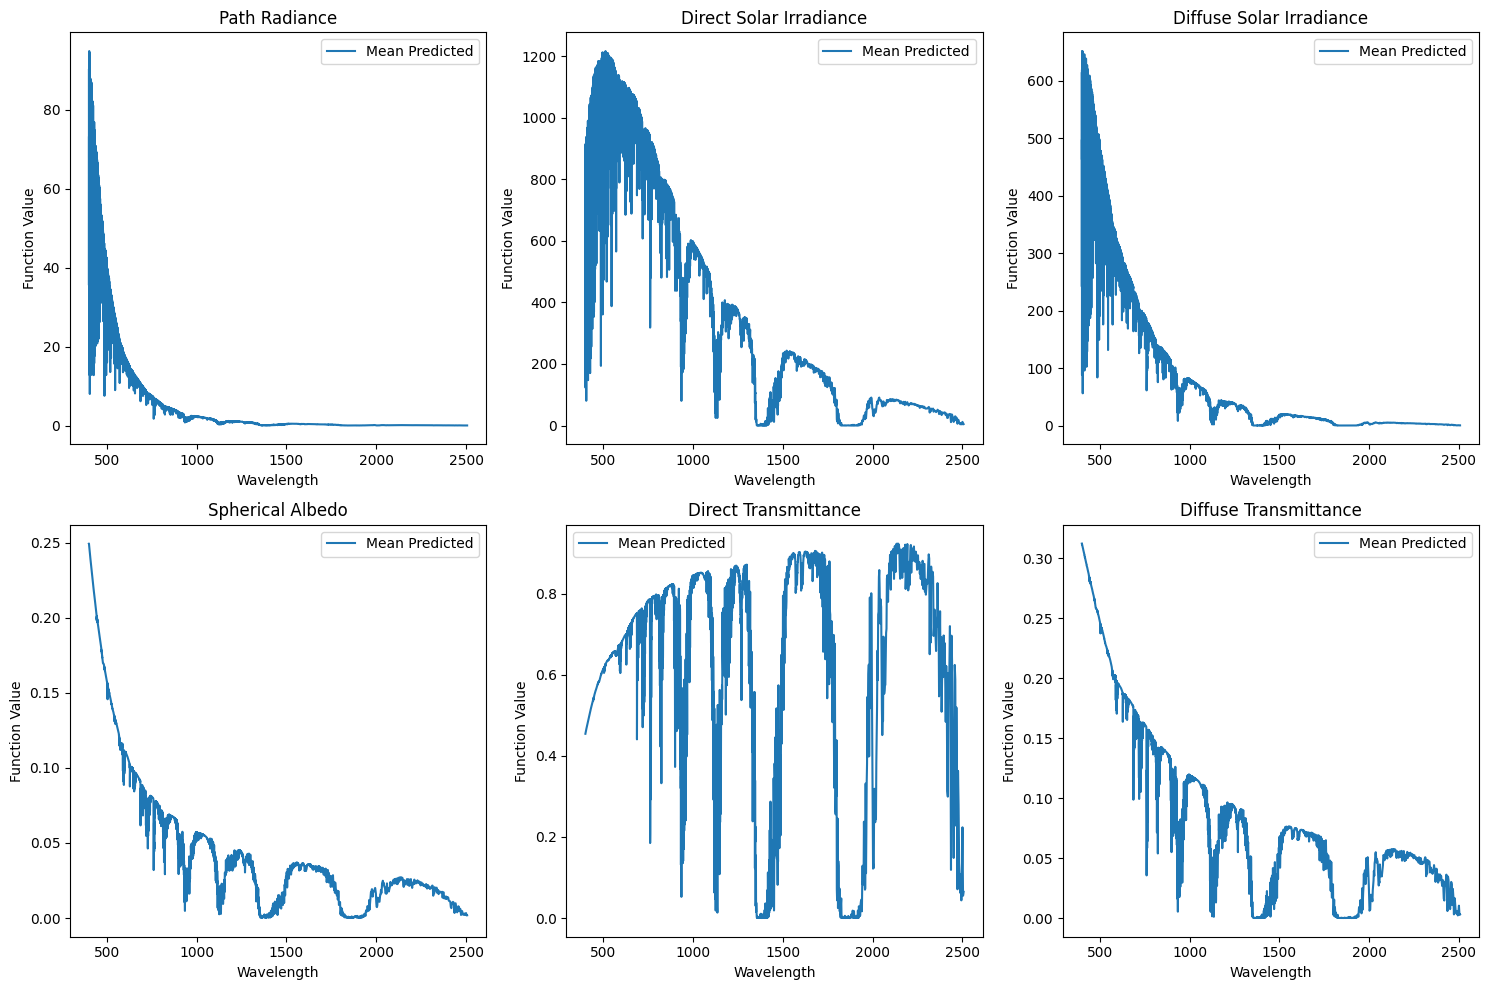

In [ ]:
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)
    plt.plot(wavelengths, np.mean(y_pred_test_np[:, i, :], axis=0), label="Mean Predicted")
    plt.title(f"{globals.function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()